# **DX 799: Week 10 — Clustering Part 1**

For this week, include the following ideas: k-means; specifically elbow method, Silhouette score, feature scaling, and distance metrics.

In [1]:
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# Reproducibility
RANDOM_SEED = 42

---

# DIABETES DATASET

In [2]:
#DIABETES: LOAD
df_diabetes = pd.read_csv("../Datasets/diabetes_cleaned.csv")
# The first few rows
df_diabetes.iloc[0:5]

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


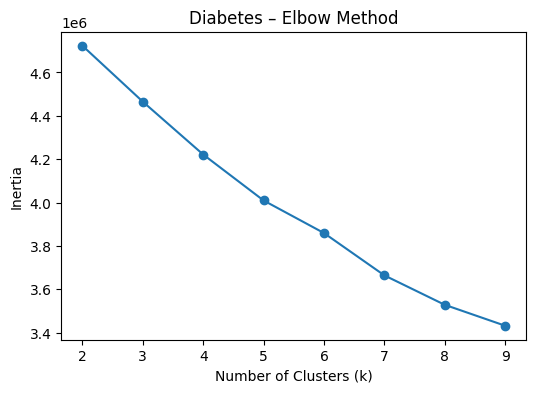

In [ ]:


# --- Select numeric features ---
X_diabetes = df_diabetes.select_dtypes("number").drop(columns=["Diabetes_012"], errors="ignore")

# --- Feature scaling ---
scaler = StandardScaler()
X_scaled_diabetes = scaler.fit_transform(X_diabetes)

# --- Elbow Method ---
inertias = []
K = range(2, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_diabetes)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Diabetes – Elbow Method")
plt.show()

# --- Silhouette Score ---
sil_scores = []
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled_diabetes)
    sil = silhouette_score(X_scaled_diabetes, labels)
    sil_scores.append(sil)

plt.figure(figsize=(6,4))
plt.plot(K, sil_scores, marker="o", color="green")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Diabetes – Silhouette Scores")
plt.show()

# --- Best K (highest silhouette score) ---
best_k = K[np.argmax(sil_scores)]
print(f"Best k for Diabetes (highest silhouette score): {best_k}")

# --- Fit final model ---
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_final = kmeans_final.fit_predict(X_scaled_diabetes)

df_diabetes["Cluster"] = labels_final
df_diabetes["Cluster"].value_counts()


---
# KIDNEY DATASET 

In [ ]:
#Kidney: LOAD
df_kidney = pd.read_csv("../Datasets/Chronic_Kidney_Dsease_data.csv")
# The first few rows
df_kidney.iloc[0:5]

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryKidneyDisease,FamilyHistoryHypertension,FamilyHistoryDiabetes,PreviousAcuteKidneyInjury,UrinaryTractInfections,SystolicBP,DiastolicBP,FastingBloodSugar,HbA1c,SerumCreatinine,BUNLevels,GFR,ProteinInUrine,ACR,SerumElectrolytesSodium,SerumElectrolytesPotassium,SerumElectrolytesCalcium,SerumElectrolytesPhosphorus,HemoglobinLevels,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,ACEInhibitors,Diuretics,NSAIDsUse,Statins,AntidiabeticMedications,Edema,FatigueLevels,NauseaVomiting,MuscleCramps,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,DoctorInCharge
0,1,71,0,0,0,2,31.069414,1,5.128112,1.676220,0.240386,4.076434,0,0,0,0,0,113,83,72.510788,9.212397,4.962531,25.605949,45.703204,0.744980,123.849426,137.652501,3.626058,10.314420,3.152648,16.114679,207.728670,85.863656,21.967957,212.095215,0,0,4.563139,1,0,0,3.563894,6.992244,4.518513,7.556302,76.076800,0,0,1,1.018824,4.966808,9.871449,1,Confidential
1,2,34,0,0,1,3,29.692119,1,18.609552,8.377574,6.503233,7.652813,1,1,0,0,0,120,67,100.848875,4.604989,3.156799,31.338166,55.784504,3.052317,88.539095,138.141335,5.332871,9.604196,2.855443,15.349205,189.450727,86.378670,87.569756,255.451314,0,0,9.097002,0,0,0,5.327336,0.356290,2.202222,6.836766,40.128498,0,0,0,3.923538,8.189275,7.161765,1,Confidential
2,3,80,1,1,0,1,37.394822,1,11.882429,9.607401,2.104828,4.392786,0,0,0,0,0,147,106,160.989441,5.432599,3.698236,39.738169,67.559032,1.157839,21.170892,142.970116,4.330891,9.885786,4.353513,13.018834,284.137622,132.269872,20.049798,251.902583,0,1,3.851249,1,0,0,4.855420,4.674069,5.967271,2.144722,92.872842,0,1,1,1.429906,7.624028,7.354632,1,Confidential
3,4,40,0,2,0,1,31.329680,0,16.020165,0.408871,6.964422,6.282274,0,0,0,0,0,117,65,188.506620,4.144466,2.868468,21.980958,33.202542,3.745871,123.779699,137.106913,3.810741,9.995894,4.016134,15.056339,235.112124,93.443669,58.260291,392.338425,0,0,7.881765,0,0,0,8.531685,5.691455,2.176387,7.077188,90.080321,0,0,0,3.226416,3.282688,6.629587,1,Confidential
4,5,43,0,1,1,2,23.726311,0,7.944146,0.780319,3.097796,4.021639,0,0,0,0,0,98,66,82.156699,4.262979,3.964877,12.216366,56.319082,2.570993,184.852046,140.627812,4.866765,8.907622,3.947907,16.690561,258.277566,171.758356,21.583213,370.523877,1,1,4.179459,1,0,0,1.422320,2.273459,6.800993,3.553118,5.258372,0,0,1,0.285466,3.849498,1.437385,1,Confidential


In [ ]:
X_kidney = df_kidney.drop(columns=["Diagnosis", "DoctorInCharge"], errors="ignore").select_dtypes("number")

# --- Scale ---
scaler = StandardScaler()
X_scaled_kidney = scaler.fit_transform(X_kidney)

# --- Elbow Method ---
inertias, sil_scores = [], []
K = range(2, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_kidney)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled_kidney, km.labels_))

plt.figure(figsize=(6,4))
plt.plot(K, inertias, marker="o")
plt.title("Kidney – Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(K, sil_scores, marker="o", color="green")
plt.title("Kidney – Silhouette Scores")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

best_k = K[np.argmax(sil_scores)]
print(f"Best k for Kidney: {best_k}")


---

# HYPERTENSION DATASET

In [ ]:
#HYPERTENSION: LOAD
df_hypertension = pd.read_csv("../Datasets/df_hypertension_clean.csv")
# The first few rows
df_hypertension.iloc[0:5]

,Country,Age,BMI,Cholesterol,Systolic_BP,Diastolic_BP,Smoking_Status,Alcohol_Intake,Physical_Activity_Level,Family_History,Diabetes,Stress_Level,Salt_Intake,Sleep_Duration,Heart_Rate,LDL,HDL,Triglycerides,Glucose,Gender,Education_Level,Employment_Status,Hypertension
0,UK,58,29.5,230,160,79,Never,27.9,Low,1,1,9,14.7,6.1,80,100,75,72,179,Female,Primary,Unemployed,1
1,Spain,34,36.2,201,120,84,Never,27.5,High,1,1,6,10.8,9.8,56,77,47,90,113,Male,Secondary,Unemployed,1
2,Indonesia,73,18.2,173,156,60,Current,1.8,High,1,1,5,6.5,5.2,75,162,56,81,101,Male,Primary,Employed,0
3,Canada,60,20.3,183,122,94,Never,11.6,Moderate,1,1,6,4.0,7.5,71,164,93,94,199,Female,Secondary,Retired,1
4,France,73,21.8,296,91,97,Never,29.1,Moderate,1,0,6,8.4,5.0,52,108,74,226,157,Female,Primary,Employed,1


In [ ]:
# One-hot encode categorical features
obj_cols_hyp = df_hypertension.select_dtypes(include="object").columns.tolist()
df_hyp_encoded = pd.get_dummies(df_hypertension, columns=obj_cols_hyp, drop_first=True)

X_hypertension = df_hyp_encoded.select_dtypes("number").drop(columns=["Hypertension", "Systolic_BP"], errors="ignore")

# --- Scale ---
scaler = StandardScaler()
X_scaled_hyp = scaler.fit_transform(X_hypertension)

# --- Elbow & Silhouette ---
inertias, sil_scores = [], []
K = range(2, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_hyp)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled_hyp, km.labels_))

plt.figure(figsize=(6,4))
plt.plot(K, inertias, marker="o")
plt.title("Hypertension – Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(K, sil_scores, marker="o", color="green")
plt.title("Hypertension – Silhouette Scores")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

best_k = K[np.argmax(sil_scores)]
print(f"Best k for Hypertension: {best_k}")
